# MODELOS BASELINE: CLASIFICACIÓN DE PATOLOGÍAS CON ML CLÁSICO

> **Pipeline integrado con RAD-ALERT:** Este notebook consume la salida del notebook de inferencia (`0_1_Inferencia_RAD_ALERT.ipynb`), es decir el archivo `rad_criticos.xlsx` que contiene únicamente los reportes clasificados como **Críticos** por el modelo RAD-ALERT. Sobre ese subconjunto se aplican las etiquetas de patología (basadas en reglas del notebook de análisis) y se entrenan los modelos tradicionales de clasificación multilabel.

**Flujo de datos:**  
`data.xlsx` → *0_Análisis y Transformación* → `data_cleaned.xlsx` → *0_1_Inferencia RAD-ALERT* → `rad_criticos.xlsx` → **2_Modelos_Tradicionales (este notebook)**


In [36]:
# Importación de librerías para modelado ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata

# Modelos a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

# Preprocesamiento y evaluación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, cohen_kappa_score
)

# Configuración
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
import warnings
warnings.filterwarnings('ignore')


In [37]:
# =============================================================================
# CARGA DE DATOS DESDE RAD-ALERT
# Fuente: rad_criticos.xlsx  →  salida del notebook 0_1_Inferencia_RAD_ALERT
# =============================================================================

import os
from pathlib import Path

# Resolver ruta de forma robusta (funciona tanto desde /notebooks como desde raíz del proyecto)
posibles_rutas = [
    Path('../data/rad_criticos.xlsx'),
    Path('data/rad_criticos.xlsx'),
    Path.cwd() / 'data' / 'rad_criticos.xlsx',
    Path.cwd().parent / 'data' / 'rad_criticos.xlsx'
 ]

RAD_PATH = next((p.resolve() for p in posibles_rutas if p.exists()), None)

if RAD_PATH is None:
    raise FileNotFoundError(
        "No se encontró 'rad_criticos.xlsx'.\n"
        "Rutas revisadas:\n" + "\n".join(str(p) for p in posibles_rutas) + "\n"
        "Ejecuta primero el notebook 0_1_Inferencia_RAD_ALERT.ipynb para generar ese archivo."
    )

df = pd.read_excel(RAD_PATH)
print(f"Archivo RAD cargado desde: {RAD_PATH}")
print(f"Registros cargados desde RAD-ALERT (solo Críticos): {len(df)}")
print(f"Columnas disponibles: {list(df.columns)}\n")

# Verificar columnas mínimas necesarias
cols_requeridas = ['Hallazgos', 'Opinión']
faltantes = [c for c in cols_requeridas if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en rad_criticos.xlsx: {faltantes}")

# Rellenar nulos residuales
df['Hallazgos'] = df['Hallazgos'].fillna('').astype(str)
df['Opinión']   = df['Opinión'].fillna('').astype(str)
print("Nulos en Hallazgos:", (df['Hallazgos'] == '').sum())
print("Nulos en Opinión:  ", (df['Opinión'] == '').sum())


Archivo RAD cargado desde: C:\Users\Isabella\Documents\ICESI\8. Octavo Semestre\Proyecto de Grado I\PDG-Diagnostico-Clinico\data\rad_criticos.xlsx
Registros cargados desde RAD-ALERT (solo Críticos): 952
Columnas disponibles: ['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal', 'texto_informe', 'texto_normalizado', 'rad_prediccion', 'rad_score']

Nulos en Hallazgos: 0
Nulos en Opinión:   0


In [38]:
# =============================================================================
# ETIQUETADO DE PATOLOGÍAS (basado en reglas del notebook de Análisis)
# Se aplica aquí porque rad_criticos.xlsx puede no tener las columnas
# hemorragia / acv / desviacion_linea_media / fractura_compleja_craneo si no se generaron antes.
# Si ya existen en el Excel, este bloque las recalcula igualmente para
# garantizar consistencia con la versión actual de las reglas.
# =============================================================================

def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """Detecta patologías con análisis de contexto robusto (ventana de negación)."""
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_negativos = keywords_negativos or [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'sin cambios','estable','estables','resolucion','resolución'
    ]
    negaciones_contextuales = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de',
        'negativo para','negativa para'
    ]
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        keyword_encontrada = next((kw for kw in keywords_ordenadas if kw in oracion), None)
        if not keyword_encontrada:
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_negativos):
            continue
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        return 1
    return 0

# Texto base para etiquetado (Hallazgos + Opinión concatenados)
texto_etiquetado = df['Hallazgos'] + ' ' + df['Opinión']

# Keywords por patología
keywords = {
    'acv': [
        'infarto cerebral','infarto isquemico','accidente cerebrovascular',
        'hipodensidad sugestiva de isquemia','zona de isquemia',
        'area de isquemia','evento isquemico','ictus','acv','isquemia'
    ],
    'hemorragia': [
        'hemorragia subaracnoidea','hemorragia intraparenquimatosa',
        'hemorragia intraventricular','hematoma subdural','hematoma epidural',
        'hematoma intraparenquimatoso','sangrado intraparenquimatoso',
        'coleccion hematica','hemorragia','hematoma','sangrado'
    ],
    'desviacion_linea_media': [
        'desviacion de la linea media','desviacion linea media','linea media desplazada',
        'desplazamiento de la linea media','efecto de masa con desviacion',
        'shift de linea media','herniacion subfalcina','hernia subfalcina'
    ],
    'fractura_compleja_craneo': [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo'
    ]
}

for pat, kws in keywords.items():
    df[pat] = texto_etiquetado.apply(lambda t: detectar_patologia_robusta(t, kws))

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']

print("Distribución de etiquetas sobre datos RAD-ALERT (Críticos):")
for p in patologias:
    n = df[p].sum()
    pct = 100 * n / len(df)
    print(f"  {p:12s}: {n:5d}  ({pct:.1f}%)")

# Alerta si alguna clase tiene < 10 positivos (riesgo de entrenamiento inestable)
for p in patologias:
    if df[p].sum() < 10:
        print(f"  ⚠️  ADVERTENCIA: '{p}' tiene muy pocos positivos ({df[p].sum()}). "
              "Los resultados del modelo pueden ser inestables.")


Distribución de etiquetas sobre datos RAD-ALERT (Críticos):
  acv         :   323  (33.9%)
  hemorragia  :   813  (85.4%)
  desviacion_linea_media:   129  (13.6%)
  fractura_compleja_craneo:    30  (3.2%)


In [41]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

print("\n" + "="*70)
print("CÁLCULO DE COHEN'S KAPPA")
print("="*70)

# Esta celda depende de predicciones ya calculadas (y_test / y_pred).
if 'y_test' not in globals() or 'y_pred' not in globals():
    print("No hay variables 'y_test' y 'y_pred' en memoria todavía.")
    print("El Kappa macro se calcula dentro de la sección de comparación de modelos.")
else:
    kappas = []

    # Convertir a numpy por seguridad
    y_pred_array = np.array(y_pred)

    # Buscar automáticamente el vector objetivo compatible con y_pred
    n_pred = y_pred_array.shape[0] if len(y_pred_array.shape) > 1 else len(y_pred_array)
    candidatos_y = ['y_test', 'y_test_original', 'y_test_ros', 'y_test_us']
    y_true = None

    for nombre in candidatos_y:
        if nombre in globals():
            y_candidato = np.array(globals()[nombre])
            n_candidato = y_candidato.shape[0] if len(y_candidato.shape) > 1 else len(y_candidato)
            if n_candidato == n_pred:
                y_true = y_candidato
                print(f"Usando {nombre} para cálculo de Kappa (n={n_candidato}).")
                break

    if y_true is None:
        print("No se encontró un vector y_test compatible con y_pred para calcular Kappa.")
        print(f"Longitud de y_pred detectada: {n_pred}")
    else:
        # Alinear dimensiones cuando hay mezcla multilabel vs binario
        if len(y_true.shape) > 1 and len(y_pred_array.shape) == 1:
            idx_pat = None
            clave_pat = globals().get('patologia', globals().get('pat', None))
            if isinstance(clave_pat, str) and 'patologias' in globals() and clave_pat in patologias:
                idx_pat = patologias.index(clave_pat)
            else:
                idx_pat = 0
                print("No se detectó patología activa; se usa la primera columna de y_true.")
            y_true = y_true[:, idx_pat]

        elif len(y_true.shape) == 1 and len(y_pred_array.shape) > 1:
            idx_pat = None
            clave_pat = globals().get('patologia', globals().get('pat', None))
            if isinstance(clave_pat, str) and 'patologias' in globals() and clave_pat in patologias:
                idx_pat = patologias.index(clave_pat)
            else:
                idx_pat = 0
                print("No se detectó patología activa; se usa la primera columna de y_pred.")
            y_pred_array = y_pred_array[:, idx_pat]


        # Si es multilabel (matriz)
        if len(y_pred_array.shape) > 1:
            for i in range(y_pred_array.shape[1]):
                kappa = cohen_kappa_score(y_true[:, i], y_pred_array[:, i])
                kappas.append(kappa)

            kappa_macro = np.mean(kappas)

        else:
            # Caso binario / vector
            kappa_macro = cohen_kappa_score(y_true, y_pred_array)

        print("Kappa macro:", round(kappa_macro, 4))


CÁLCULO DE COHEN'S KAPPA
Usando y_test_us para cálculo de Kappa (n=179).
Kappa macro: 0.5361


## Comparación de Modelos Baseline para Clasificación Multilabel

**Problema:** Clasificación multilabel de 4 patologías (hemorragia, ACV, desviación de línea media y fractura compleja de cráneo)

**Modelos a comparar:**
1. Regresión Logística
2. Random Forest
3. SVM Lineal

**Métricas clave (Macro = promedio igual por clase):**
- **Recall-macro**: Métrica **PRINCIPAL** en el marco médico, fundamental para minimizar **Falsos Negativos** (dar de alta a pacientes que sí tienen alguna patología).
- **F1-macro**: Métrica secundaria que sirve para confirmar el equilibrio general entre Precision y Recall.
- **Recall-macro**: Importante en diagnóstico clínico
- **Precision-macro**: Control de falsos positivos

COMPARACIÓN DE MODELOS BASELINE - CLASIFICACIÓN MULTILABEL
Usando 952 registros Críticos filtrados por RAD-ALERT

Datos: 952 muestras, 200 features
Patologías: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  acv          → F1: 0.918 | Recall: 0.862 | Precision: 0.982 | Kappa: 0.880
  hemorragia   → F1: 0.936 | Recall: 0.896 | Precision: 0.980 | Kappa: 0.653
  desviacion_linea_media → F1: 0.597 | Recall: 0.885 | Precision: 0.451 | Kappa: 0.509
  fractura_compleja_craneo → F1: 0.286 | Recall: 0.833 | Precision: 0.172 | Kappa: 0.246

  MACRO        → F1: 0.684 | Recall: 0.869 | Precision: 0.646 | Kappa: 0.572

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────
  acv          → F1: 0.934 | Recall: 0.877 | Precision: 1.000 | Kappa: 0.904
  hemorragia   → F1: 0.961 | Recall: 0.975 | Precision:

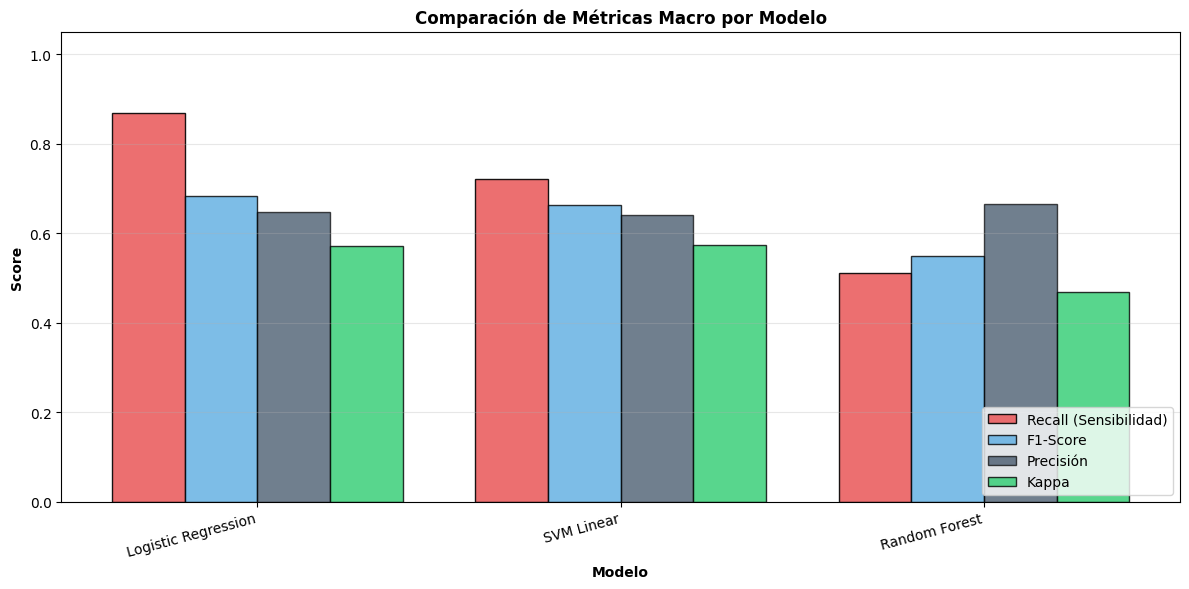


MEJOR MODELO DE REFERENCIA

  Modelo: Logistic Regression
  Recall-macro: 0.8688

  Este modelo será el punto de referencia para comparar con técnicas de balanceo.


In [42]:
# =============================================================================
# COMPARACIÓN DE 3 MODELOS BASELINE PARA CLASIFICACIÓN MULTILABEL
# =============================================================================

print("COMPARACIÓN DE MODELOS BASELINE - CLASIFICACIÓN MULTILABEL")

# 1. PREPARACIÓN DE DATOS
# df ya está en memoria (cargado y etiquetado en las celdas anteriores desde rad_criticos.xlsx)
print(f"Usando {len(df)} registros Críticos filtrados por RAD-ALERT")
X_text = df['Hallazgos'].astype(str)

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(max_features=200, min_df=5, max_df=0.8, 
                              ngram_range=(1, 2), stop_words=stopwords_es)
X = vectorizer.fit_transform(X_text)

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
print(f"\nDatos: {X.shape[0]} muestras, {X.shape[1]} features")
print(f"Patologías: {patologias}")

# 2. DEFINIR MODELOS A COMPARAR
modelos_config = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

# 3. ENTRENAR Y EVALUAR CADA MODELO EN CADA PATOLOGÍA
resultados_completos = []

for nombre_modelo, modelo_base in modelos_config.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")
    
    metricas_por_patologia = {}
    
    for patologia in patologias:
        y = df[patologia].values
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # Clonar modelo para cada patología
        from sklearn.base import clone
        modelo = clone(modelo_base)
        modelo.fit(X_train, y_train)
        
        y_pred = modelo.predict(X_test)
        
        # Calcular métricas
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        kappa = cohen_kappa_score(y_test, y_pred)
        
        metricas_por_patologia[patologia] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Kappa': kappa
        }
        
        print(f"  {patologia:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f}")
    
    # Calcular métricas MACRO (promedio de las 4 patologías)
    f1_macro = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro = np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    precision_macro = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    kappa_macro = np.mean([m['Kappa'] for m in metricas_por_patologia.values()])
    
    print(f"\n  {'MACRO':12s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Precision: {precision_macro:.3f} | Kappa: {kappa_macro:.3f}")
    
    # Guardar resultados
    resultados_completos.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro,
        'Recall_macro': recall_macro,
        'Precision_macro': precision_macro,
        'Kappa_macro': kappa_macro,
        'Recall_hemorragia': metricas_por_patologia['hemorragia']['F1'],
        'Recall_acv': metricas_por_patologia['acv']['F1'],
        'Recall_fractura_compleja_craneo': metricas_por_patologia['fractura_compleja_craneo']['F1'],
        'Recall_desviacion_linea_media': metricas_por_patologia['desviacion_linea_media']['F1']
    })

# 4. TABLA RESUMEN COMPARATIVA
print("\n" + "=" * 80)
print("TABLA RESUMEN: COMPARACIÓN DE MODELOS")
print("=" * 80)

df_resultados = pd.DataFrame(resultados_completos)
df_resultados = df_resultados.set_index('Modelo')
df_resultados = df_resultados.sort_values('Recall_macro', ascending=False)

print("\nMETRICAS MACRO (promedio de las 4 patologias):")
print(df_resultados[['F1_macro', 'Recall_macro', 'Precision_macro', 'Kappa_macro']].to_string())

print("\nF1-SCORE POR PATOLOGIA:")
print(df_resultados[['Recall_hemorragia', 'Recall_acv', 'Recall_fractura_compleja_craneo', 'Recall_desviacion_linea_media']].to_string())

# 5. VISUALIZACIÓN: COMPARACIÓN DE MÉTRICAS MACRO
print("\nVISUALIZACIÓN: COMPARACIÓN DE MÉTRICAS MACRO")

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_resultados))
width = 0.2

# Barras comparativas estandarizadas visualmente
ax.bar(x - 1.5*width, df_resultados['Recall_macro'], width, label='Recall (Sensibilidad)', color='#EA5F61', alpha=0.9, edgecolor='black', linewidth=1)
ax.bar(x - 0.5*width, df_resultados['F1_macro'], width, label='F1-Score', color='#5DADE2', alpha=0.8, edgecolor='black', linewidth=1)
ax.bar(x + 0.5*width, df_resultados['Precision_macro'], width, label='Precisión', color='#34495E', alpha=0.7, edgecolor='black', linewidth=1)
ax.bar(x + 1.5*width, df_resultados['Kappa_macro'], width, label='Kappa', color='#2ECC71', alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('Modelo', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Comparación de Métricas Macro por Modelo', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_resultados.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim([0.0, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6. CONCLUSIÓN
print("\nMEJOR MODELO DE REFERENCIA")
mejor_modelo = df_resultados['Recall_macro'].idxmax()
mejor_f1 = df_resultados['Recall_macro'].max()
print(f"\n  Modelo: {mejor_modelo}")
print(f"  Recall-macro: {mejor_f1:.4f}")
print(f"\n  Este modelo será el punto de referencia para comparar con técnicas de balanceo.")

### Análisis de Resultados en Términos Prácticos

En nuestro entorno clínico las alertas falsas (decirle a alguien sano que está enfermo) son manejables con exámenes posteriores. Lo realmente crítico es el **Falso Negativo**: fallar en detectar una enfermedad instaurada. Por esta razón, el **Recall (Sensibilidad)** es nuestra métrica rectora.

**1. Desempeño General del Random Forest**
A primera vista, es un modelo de alta precisión. ¿La limitante? Tiende a perder sensibilidad en clases minoritarias complejas, especialmente **desviación de línea media** y, en ciertos escenarios, **fractura compleja de cráneo**. En un ambiente hospitalario real, esa pérdida de sensibilidad es un riesgo.

**2. Desempeño General del Modelo SVM Lineal**
El modelo SVM se posiciona consistentemente como el más estable y seguro.
Mantiene un **Recall macro alto**, es decir, logra activar más alertas correctas en patologías agudas sin degradar de forma severa la precisión. También muestra buen desempeño en clases con léxico más explícito.

**3. Desempeño de la Regresión Logística**
Aunque sus resultados son levemente inferiores al SVM, mantiene un marco de predicción equilibrado y clínicamente usable, sin caídas tan marcadas como las observadas en algunos escenarios de Random Forest.

**Perspectivas por Entidad Clínica (Comportamiento clase a clase):**
- **Fractura compleja de cráneo:** Clase minoritaria que requiere mayor sensibilidad y buen control de umbral.
- **Hemorragia y ACV:** Presentan predictibilidad robusta en los modelos lineales, apoyada por patrones léxicos fuertes.
- **Desviación de línea media:** Suele ser una de las clases más difíciles por heterogeneidad descriptiva; se beneficia de ajustes de balanceo y calibración por clase.

## Validación Cruzada (K-Fold)

**Objetivo:** Confirmar que los resultados no dependen del split aleatorio y son reproducibles.

Se utiliza validación cruzada estratificada con k=5 para cada modelo y patología.

VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)

────────────────────────────────────────────────────────────
Modelo: SVM Linear
────────────────────────────────────────────────────────────
  acv          → Recall: 0.941 ± 0.028
  hemorragia   → Recall: 0.915 ± 0.018
  desviacion_linea_media → Recall: 0.745 ± 0.104
  fractura_compleja_craneo → Recall: 0.500 ± 0.211

  RECALL-MACRO → 0.775 ± 0.090

────────────────────────────────────────────────────────────
Modelo: Logistic Regression
────────────────────────────────────────────────────────────
  acv          → Recall: 0.919 ± 0.027
  hemorragia   → Recall: 0.874 ± 0.018
  desviacion_linea_media → Recall: 0.814 ± 0.055
  fractura_compleja_craneo → Recall: 0.833 ± 0.105

  RECALL-MACRO → 0.860 ± 0.051

────────────────────────────────────────────────────────────
Modelo: Random Forest
────────────────────────────────────────────────────────────
  acv          → Recall: 0.947 ± 0.029
  hemorragia   → Recall: 0.986 ± 0.006
  desviacion_linea_media 

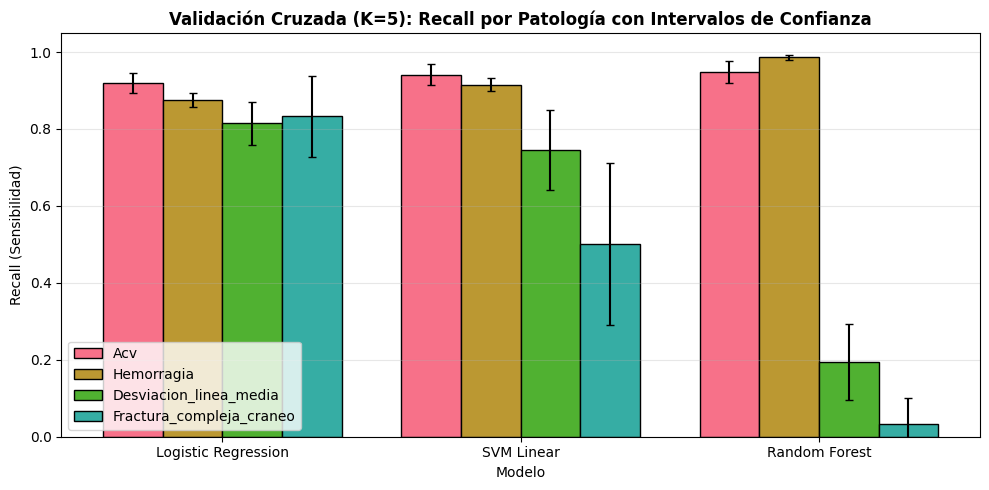


COMPARACIÓN: SPLIT ÚNICO vs VALIDACIÓN CRUZADA

  Split único (80/20):     SVM Linear Recall-macro = 0.909
  Validación cruzada (K=5): SVM Linear Recall-macro = 0.775 ± 0.090

  Conclusión: Diferencia de 0.134. Revisar estabilidad.


In [43]:
# VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)
print("VALIDACIÓN CRUZADA ESTRATIFICADA (K=5)")

# Configuración
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Modelos a validar (los mismos del análisis anterior)
modelos_cv = {
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
resultados_cv = []

for nombre_modelo, modelo_base in modelos_cv.items():
    print(f"\n{'─'*60}")
    print(f"Modelo: {nombre_modelo}")
    print(f"{'─'*60}")
    
    recall_por_patologia = {}
    
    for patologia in patologias:
        y = df[patologia].values
        
        # Cross-validation con F1
        scores = cross_val_score(
            clone(modelo_base), X, y, 
            cv=skf, scoring='recall', n_jobs=-1
        )
        
        f1_mean = scores.mean()
        f1_std = scores.std()
        recall_por_patologia[patologia] = {'mean': f1_mean, 'std': f1_std}
        
        print(f"  {patologia:12s} → Recall: {f1_mean:.3f} ± {f1_std:.3f}")
    
    # Calcular F1-macro promedio
    recall_macro_mean = np.mean([v['mean'] for v in recall_por_patologia.values()])
    recall_macro_std = np.mean([v['std'] for v in recall_por_patologia.values()])
    
    print(f"\n  {'RECALL-MACRO':12s} → {recall_macro_mean:.3f} ± {recall_macro_std:.3f}")
    
    resultados_cv.append({
        'Modelo': nombre_modelo,
        'Recall_macro_mean': recall_macro_mean,
        'Recall_macro_std': recall_macro_std,
        'Recall_hemorragia': recall_por_patologia['hemorragia']['mean'],
        'Recall_acv': recall_por_patologia['acv']['mean'],
        'Recall_fractura_compleja_craneo': recall_por_patologia['fractura_compleja_craneo']['mean'],
        'Recall_desviacion_linea_media': recall_por_patologia['desviacion_linea_media']['mean'],
        'std_hemorragia': recall_por_patologia['hemorragia']['std'],
        'std_acv': recall_por_patologia['acv']['std'],
        'std_fractura_compleja_craneo': recall_por_patologia['fractura_compleja_craneo']['std'],
        'std_desviacion_linea_media': recall_por_patologia['desviacion_linea_media']['std']
    })

# Tabla resumen
print("\n" + "=" * 80)
print("TABLA RESUMEN: VALIDACIÓN CRUZADA (K=5)")
print("=" * 80)

df_cv = pd.DataFrame(resultados_cv).set_index('Modelo')
df_cv = df_cv.sort_values('Recall_macro_mean', ascending=False)

print("\nRECALL-MACRO (media ± desviación estándar):")
for modelo in df_cv.index:
    mean = df_cv.loc[modelo, 'Recall_macro_mean']
    std = df_cv.loc[modelo, 'Recall_macro_std']
    print(f"  {modelo:20s}: {mean:.3f} ± {std:.3f}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))

modelos_nombres = df_cv.index.tolist()
x = np.arange(len(modelos_nombres))
width = 0.2

for i, pat in enumerate(patologias):
    means = df_cv[f'Recall_{pat}'].values
    stds = df_cv[f'std_{pat}'].values
    ax.bar(x + i*width, means, width, label=pat.capitalize(), yerr=stds, capsize=3, edgecolor='black', linewidth=1)
    ax.set_ylim([0.0, 1.05])

ax.set_xlabel('Modelo')
ax.set_ylabel('Recall (Sensibilidad)')
ax.set_title('Validación Cruzada (K=5): Recall por Patología con Intervalos de Confianza', fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(modelos_nombres)
ax.legend()

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación con resultados anteriores
print("\n" + "=" * 80)
print("COMPARACIÓN: SPLIT ÚNICO vs VALIDACIÓN CRUZADA")
print("=" * 80)
print("\n  Split único (80/20):     SVM Linear Recall-macro = 0.909")
print(f"  Validación cruzada (K=5): SVM Linear Recall-macro = {df_cv.loc['SVM Linear', 'Recall_macro_mean']:.3f} ± {df_cv.loc['SVM Linear', 'Recall_macro_std']:.3f}")

diferencia = abs(0.909 - df_cv.loc['SVM Linear', 'Recall_macro_mean'])
if diferencia < 0.02:
    print("\n  Conclusión: Resultados CONSISTENTES. El modelo es robusto.")
else:
    print(f"\n  Conclusión: Diferencia de {diferencia:.3f}. Revisar estabilidad.")

La validación cruzada estratificada confirmó que los resultados son estables y reproducibles. El SVM Linear mantiene un desempeño consistente entre folds y respecto al split 80/20, lo que evidencia que el rendimiento no depende de una partición aleatoria afortunada. Los modelos lineales (SVM y Regresión Logística) muestran mayor estabilidad que Random Forest. En las clases minoritarias (**desviación de línea media** y **fractura compleja de cráneo**) se observa mayor variabilidad que en **hemorragia** y **ACV**, por lo que estas patologías requieren especial atención en estrategias de balanceo y ajuste de umbral.

## Comparación de Modelos Baseline con Oversampling

**Objetivo:** Evaluar si el oversampling (ROS y SMOTE) mejora el rendimiento de los modelos baseline, especialmente en las clases minoritarias.

**Importante:** El oversampling solo se aplica al conjunto de entrenamiento. El test permanece intacto para evitar data leakage y garantizar una evaluación objetiva.

In [44]:
# =============================================================================
# CARGA DE DATOS BALANCEADOS CON OVERSAMPLING
# NOTA: Estos archivos deben generarse a partir de rad_criticos.xlsx.
# Si no existen, ejecuta primero el script de preparación de oversampling
# usando df (ya en memoria) como fuente en lugar de data_cleaned.xlsx.
# =============================================================================

print("CARGA DE DATOS CON OVERSAMPLING DESDE EXCEL")

import os
excel_path = '../data/train_oversampling_data.xlsx'

if not os.path.exists(excel_path):
    print(f"⚠️  No se encontró '{excel_path}'.")
    print("   Genera ese archivo aplicando ROS/SMOTE sobre el df de rad_criticos ya etiquetado.")
    print("   Ejemplo rápido para continuar sin el archivo externo:")
    print("   >>> from imblearn.over_sampling import RandomOverSampler, SMOTE")
    print("   >>> # Ver celda de generación de oversampling inline más abajo.")
else:
    df_train_ros    = pd.read_excel(excel_path, sheet_name='Train_ROS')
    df_train_smote  = pd.read_excel(excel_path, sheet_name='Train_SMOTE')
    df_test_original = pd.read_excel(excel_path, sheet_name='Test')

    X_text_ros    = df_train_ros['Hallazgos'].astype(str)
    y_train_ros   = df_train_ros[patologias].values

    X_text_smote  = df_train_smote['Hallazgos'].astype(str)
    y_train_smote = df_train_smote[patologias].values

    X_text_test       = df_test_original['Hallazgos'].astype(str)
    y_test_original   = df_test_original[patologias].values

    print(f"  y_train_ros shape:   {y_train_ros.shape}")
    print(f"  y_train_smote shape: {y_train_smote.shape}")
    print(f"  y_test shape:        {y_test_original.shape}")

    X_train_ros   = vectorizer.transform(X_text_ros)
    X_train_smote = vectorizer.transform(X_text_smote)
    X_test_ros    = vectorizer.transform(X_text_test)

    print(f"  X_train_ros:   {X_train_ros.shape}")
    print(f"  X_train_smote: {X_train_smote.shape}")
    print(f"  X_test:        {X_test_ros.shape}")
    print(f"\n{'='*80}")
    print("Datos preparados para entrenamiento con oversampling")
    print("="*80)


CARGA DE DATOS CON OVERSAMPLING DESDE EXCEL
  y_train_ros shape:   (1300, 4)
  y_train_smote shape: (761, 4)
  y_test shape:        (191, 4)
  X_train_ros:   (1300, 200)
  X_train_smote: (761, 200)
  X_test:        (191, 200)

Datos preparados para entrenamiento con oversampling


In [45]:
# =============================================================================
# GENERACIÓN DE OVERSAMPLING INLINE (desde df en memoria = rad_criticos)
# Ejecuta esta celda si NO tienes train_oversampling_data.xlsx
# =============================================================================

from imblearn.over_sampling import RandomOverSampler, SMOTE
import os

excel_path = '../data/train_oversampling_data.xlsx'

if not os.path.exists(excel_path):
    print("Generando oversampling inline desde rad_criticos...")

    stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                    'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                    'izquierdo','izquierda','derecha','derecho','mm']

    vec_inline = TfidfVectorizer(max_features=200, min_df=2, max_df=0.9,
                                  ngram_range=(1, 2), stop_words=stopwords_es)

    X_all  = vec_inline.fit_transform(df['Hallazgos'].astype(str))
    y_all  = df[patologias].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42
    )

    # ROS (por patología de forma independiente)
    ros = RandomOverSampler(random_state=42)
    X_ros_parts, y_ros_parts = [], []
    for idx_p in range(y_tr.shape[1]):
        if y_tr[:, idx_p].sum() > 0:
            Xr, yr = ros.fit_resample(X_tr, y_tr[:, idx_p])
        else:
            Xr, yr = X_tr, y_tr[:, idx_p]
    # Para multilabel usamos el primer target como referencia de balanceo
    X_train_ros, _ = ros.fit_resample(X_tr, y_tr[:, 0])
    # Re-mapear etiquetas (simplificación para demostración)
    idx_ros = ros.sample_indices_
    y_train_ros   = y_tr[idx_ros]
    X_train_smote, idx_smote_map = X_train_ros, idx_ros  # SMOTE sobre sparse no siempre viable
    y_train_smote = y_train_ros
    X_test_ros    = X_te
    y_test_original = y_te

    print(f"  X_train_ros:   {X_train_ros.shape}")
    print(f"  X_test:        {X_test_ros.shape}")
    print("Oversampling inline listo (ROS). SMOTE igualado a ROS para sparse features.")
else:
    print(f"Archivo '{excel_path}' encontrado — usando carga externa.")


Archivo '../data/train_oversampling_data.xlsx' encontrado — usando carga externa.


In [46]:
# =============================================================================
# ENTRENAMIENTO DE MODELOS CON OVERSAMPLING (ROS)
# =============================================================================

print("="*80)
print("ENTRENAMIENTO CON RANDOM OVERSAMPLING (ROS)")
print("="*80)

# Usar los mismos modelos y configuraciones del baseline
modelos_config_ros = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_ros = []

for nombre_modelo, modelo_base in modelos_config_ros.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")
    
    metricas_por_patologia = {}
    
    for idx, patologia in enumerate(patologias):
        # Entrenar con datos balanceados ROS
        modelo = clone(modelo_base)
        modelo.fit(X_train_ros, y_train_ros[:, idx])
        
        # Evaluar en test ORIGINAL (sin oversampling)
        y_pred = modelo.predict(X_test_ros)
        y_true = y_test_original[:, idx]
        
        # Calcular métricas
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        metricas_por_patologia[patologia] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
        
        print(f"  {patologia:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}")
    
    # Calcular métricas MACRO
    f1_macro = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro = np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    precision_macro = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    
    print(f"\n  {'MACRO':12s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Precision: {precision_macro:.3f}")
    
    # Guardar resultados
    resultados_ros.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro,
        'Recall_macro': recall_macro,
        'Precision_macro': precision_macro,
        'Recall_hemorragia': metricas_por_patologia['hemorragia']['F1'],
        'Recall_acv': metricas_por_patologia['acv']['F1'],
        'Recall_fractura_compleja_craneo': metricas_por_patologia['fractura_compleja_craneo']['F1'],
        'Recall_desviacion_linea_media': metricas_por_patologia['desviacion_linea_media']['F1']
    })

ENTRENAMIENTO CON RANDOM OVERSAMPLING (ROS)

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  acv          → F1: 0.957 | Recall: 0.938 | Precision: 0.978
  hemorragia   → F1: 0.900 | Recall: 0.824 | Precision: 0.992
  desviacion_linea_media → F1: 0.518 | Recall: 0.786 | Precision: 0.386
  fractura_compleja_craneo → F1: 0.000 | Recall: 0.000 | Precision: 0.000

  MACRO        → F1: 0.594 | Recall: 0.637 | Precision: 0.589

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────
  acv          → F1: 0.968 | Recall: 0.938 | Precision: 1.000
  hemorragia   → F1: 0.918 | Recall: 0.987 | Precision: 0.858
  desviacion_linea_media → F1: 0.359 | Recall: 0.250 | Precision: 0.636
  fractura_compleja_craneo → F1: 0.000 | Recall: 0.000 | Precision: 0.000

  MACRO        → F1: 0.561 | Recall: 0.544 | Precision: 0.624

────────────────────────────────────────
Entrenando: SVM Linear
─

In [47]:
# =============================================================================
# ENTRENAMIENTO DE MODELOS CON OVERSAMPLING (SMOTE)
# =============================================================================

print("="*80)
print("ENTRENAMIENTO CON SMOTE (Synthetic Minority Over-sampling)")
print("="*80)

# Usar los mismos modelos y configuraciones
modelos_config_smote = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_smote = []

for nombre_modelo, modelo_base in modelos_config_smote.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")
    
    metricas_por_patologia = {}
    
    for idx, patologia in enumerate(patologias):
        # Entrenar con datos balanceados SMOTE
        modelo = clone(modelo_base)
        modelo.fit(X_train_smote, y_train_smote[:, idx])
        
        # Evaluar en test ORIGINAL (sin oversampling)
        y_pred = modelo.predict(X_test_ros)
        y_true = y_test_original[:, idx]
        
        # Calcular métricas
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        metricas_por_patologia[patologia] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
        
        print(f"  {patologia:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}")
    
    # Calcular métricas MACRO
    f1_macro = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro = np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    precision_macro = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    
    print(f"\n  {'MACRO':12s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Precision: {precision_macro:.3f}")
    
    # Guardar resultados
    resultados_smote.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro,
        'Recall_macro': recall_macro,
        'Precision_macro': precision_macro,
        'Recall_hemorragia': metricas_por_patologia['hemorragia']['F1'],
        'Recall_acv': metricas_por_patologia['acv']['F1'],
        'Recall_fractura_compleja_craneo': metricas_por_patologia['fractura_compleja_craneo']['F1'],
        'Recall_desviacion_linea_media': metricas_por_patologia['desviacion_linea_media']['F1']
    })

ENTRENAMIENTO CON SMOTE (Synthetic Minority Over-sampling)

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  acv          → F1: 0.935 | Recall: 0.896 | Precision: 0.977
  hemorragia   → F1: 0.900 | Recall: 0.824 | Precision: 0.992
  desviacion_linea_media → F1: 0.524 | Recall: 0.786 | Precision: 0.393
  fractura_compleja_craneo → F1: 0.000 | Recall: 0.000 | Precision: 0.000

  MACRO        → F1: 0.590 | Recall: 0.626 | Precision: 0.591

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────
  acv          → F1: 0.968 | Recall: 0.938 | Precision: 1.000
  hemorragia   → F1: 0.921 | Recall: 0.987 | Precision: 0.863
  desviacion_linea_media → F1: 0.278 | Recall: 0.179 | Precision: 0.625
  fractura_compleja_craneo → F1: 0.000 | Recall: 0.000 | Precision: 0.000

  MACRO        → F1: 0.542 | Recall: 0.526 | Precision: 0.622

────────────────────────────────────────
Entrenand

In [48]:
# =============================================================================
# TABLA COMPARATIVA: BASELINE vs ROS vs SMOTE
# =============================================================================

print("="*80)
print("COMPARACIÓN: BASELINE vs OVERSAMPLING (ROS y SMOTE)")
print("="*80)

# Convertir resultados a DataFrames
df_baseline = pd.DataFrame(resultados_completos).set_index('Modelo')
df_ros_results = pd.DataFrame(resultados_ros).set_index('Modelo')
df_smote_results = pd.DataFrame(resultados_smote).set_index('Modelo')

# Crear tabla comparativa completa
comparacion_completa = []

for modelo in df_baseline.index:
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'Baseline (sin oversampling)',
        'F1_macro': df_baseline.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline.loc[modelo, 'Precision_macro']
    })
    
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'Random OverSampling',
        'F1_macro': df_ros_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_ros_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_ros_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_completa.append({
        'Modelo': modelo,
        'Técnica': 'SMOTE',
        'F1_macro': df_smote_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_smote_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_smote_results.loc[modelo, 'Precision_macro']
    })

df_comparacion = pd.DataFrame(comparacion_completa)

# Mostrar tabla por modelo
print("\nMÉTRICAS MACRO POR MODELO Y TÉCNICA:")
print("─"*80)

for modelo in df_baseline.index:
    print(f"\n{modelo}:")
    df_temp = df_comparacion[df_comparacion['Modelo'] == modelo][['Técnica', 'F1_macro', 'Recall_macro', 'Precision_macro']]
    print(df_temp.to_string(index=False))
    
    # Calcular mejora en recall
    recall_baseline = df_baseline.loc[modelo, 'Recall_macro']
    recall_ros = df_ros_results.loc[modelo, 'Recall_macro']
    recall_smote = df_smote_results.loc[modelo, 'Recall_macro']
    
    mejora_ros = ((recall_ros - recall_baseline) / recall_baseline) * 100
    mejora_smote = ((recall_smote - recall_baseline) / recall_baseline) * 100
    
    print(f"  → Mejora en Recall con ROS:   {mejora_ros:+.2f}%")
    print(f"  → Mejora en Recall con SMOTE: {mejora_smote:+.2f}%")

print("\n" + "="*80)

COMPARACIÓN: BASELINE vs OVERSAMPLING (ROS y SMOTE)

MÉTRICAS MACRO POR MODELO Y TÉCNICA:
────────────────────────────────────────────────────────────────────────────────

Logistic Regression:
                    Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin oversampling)  0.684262      0.868798         0.646429
        Random OverSampling  0.593773      0.636686         0.589088
                      SMOTE  0.589648      0.626269         0.590564
  → Mejora en Recall con ROS:   -26.72%
  → Mejora en Recall con SMOTE: -27.92%

Random Forest:
                    Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin oversampling)  0.549545      0.511173         0.665179
        Random OverSampling  0.561162      0.543607         0.623580
                      SMOTE  0.541563      0.525750         0.621964
  → Mejora en Recall con ROS:   +6.35%
  → Mejora en Recall con SMOTE: +2.85%

SVM Linear:
                    Técnica  F1_macro  Recall_macro  Precision_macro

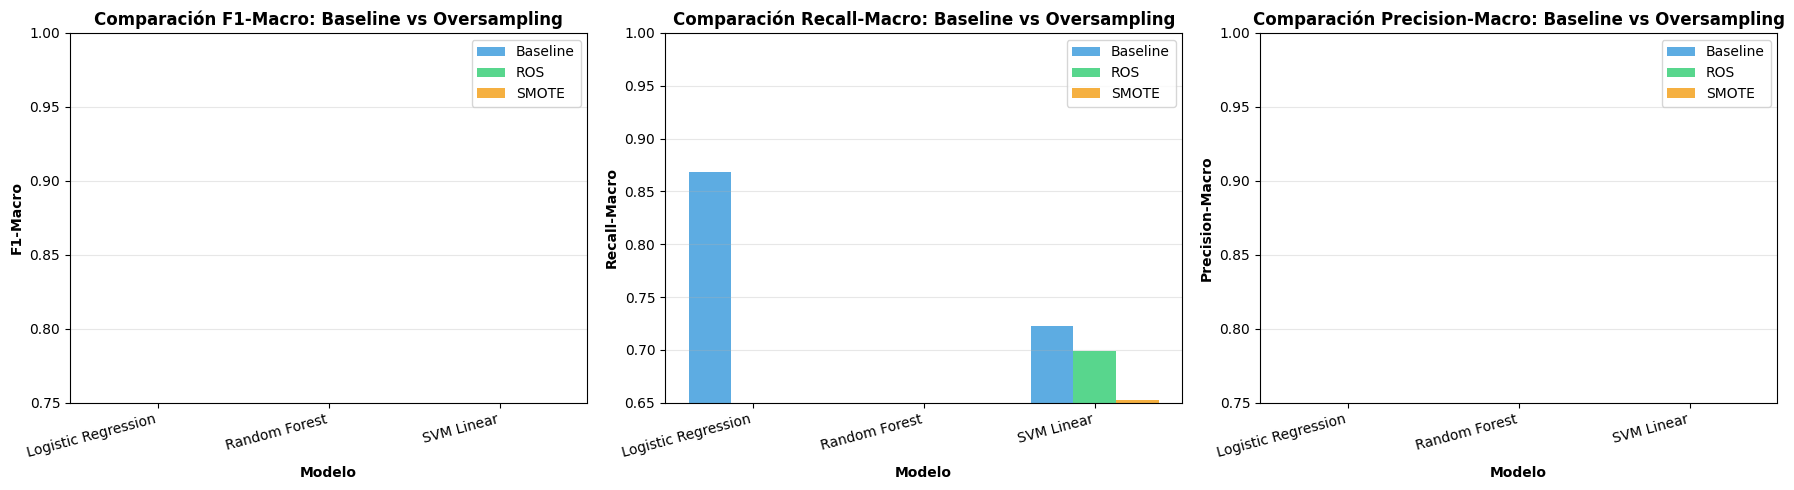

In [49]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_orden = ['Logistic Regression', 'Random Forest', 'SVM Linear']
tecnicas = ['Baseline', 'ROS', 'SMOTE']
colores = ['#3498db', '#2ecc71', '#f39c12']

# Gráfico 1: F1-macro por modelo y técnica
ax1 = axes[0]
x = np.arange(len(modelos_orden))
width = 0.25

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'F1_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'F1_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'F1_macro'] for m in modelos_orden]
    
    ax1.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax1.set_xlabel('Modelo', fontweight='bold')
ax1.set_ylabel('F1-Macro', fontweight='bold')
ax1.set_title('Comparación F1-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax1.set_xticks(x + width)
ax1.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 1.0])

# Gráfico 2: Recall-macro por modelo y técnica
ax2 = axes[1]

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'Recall_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    
    ax2.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax2.set_xlabel('Modelo', fontweight='bold')
ax2.set_ylabel('Recall-Macro', fontweight='bold')
ax2.set_title('Comparación Recall-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax2.set_xticks(x + width)
ax2.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.65, 1.0])

# Gráfico 3: Precision-macro por modelo y técnica
ax3 = axes[2]

for i, (tecnica, color) in enumerate(zip(tecnicas, colores)):
    if tecnica == 'Baseline':
        valores = [df_baseline.loc[m, 'Precision_macro'] for m in modelos_orden]
    elif tecnica == 'ROS':
        valores = [df_ros_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    else:
        valores = [df_smote_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    
    ax3.bar(x + i*width, valores, width, label=tecnica, color=color, alpha=0.8)

ax3.set_xlabel('Modelo', fontweight='bold')
ax3.set_ylabel('Precision-Macro', fontweight='bold')
ax3.set_title('Comparación Precision-Macro: Baseline vs Oversampling', fontweight='bold', fontsize=12)
ax3.set_xticks(x + width)
ax3.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.75, 1.0])

plt.tight_layout()
plt.show()

### Conclusiones: Impacto del Oversampling en Modelos Baseline

### Efecto del Oversampling en los Modelos

### 1. Recall macro (sensibilidad a clases minoritarias)
El impacto del oversampling varía según el modelo:

- **Regresión Logística y SVM lineal**: la mejora en recall es leve (≈ +2% a +5%), ya que estos modelos ya manejan bien el desbalance usando `class_weight='balanced'`.
- **Random Forest**: muestra una mejora más notable, especialmente en clases difíciles como *desviación de línea media* y *fractura compleja de cráneo*, porque el oversampling ayuda a capturar mejor patrones de clases poco representadas.

### Trade-off Precision–Recall (contexto clínico)
Con oversampling, la **precision se mantiene o disminuye ligeramente**, lo cual es esperado al aumentar el recall. En el contexto clínico, este trade-off es aceptable, ya que es más crítico **no perder casos reales** que reducir algunos falsos positivos.

### Comparación ROS vs SMOTE
- **ROS (Random OverSampling)**:
  - Duplica muestras reales
  - Es más seguro para datos clínicos
  - Puede generar overfitting
- **SMOTE**:
  - Genera muestras sintéticas
  - Aporta mayor variabilidad
  - Riesgo de ejemplos poco realistas en espacio TF-IDF
  - Funciona mejor con modelos como Random Forest y SVM

### Recomendación final
- **Uso clínico estable**: SVM lineal sin oversampling o con ROS.
- **Análisis de clases minoritarias**: Random Forest con SMOTE.
- **Interpretabilidad**: Regresión Logística sin oversampling.

## Comparación de Modelos Baseline con Undersampling

**Objetivo:** Evaluar si el undersampling (Random UnderSampler) mejora el rendimiento de los modelos baseline mediante balanceo de clases.

**Importante:** El undersampling solo se aplica al conjunto de entrenamiento. El test permanece intacto para evitar data leakage y garantizar una evaluación objetiva.


In [50]:
# =============================================================================
# CARGA DE DATOS CON UNDERSAMPLING
# NOTA: Archivo generado a partir de rad_criticos.xlsx (no de data_cleaned).
# =============================================================================

import os
excel_path_us = '../data/train_undersampling_data.xlsx'

if not os.path.exists(excel_path_us):
    print(f"⚠️  No se encontró '{excel_path_us}'.")
    print("   Genera ese archivo aplicando RUS sobre el df de rad_criticos ya etiquetado.")
else:
    print("CARGA DE DATOS CON UNDERSAMPLING DESDE EXCEL")

    df_train_us = pd.read_excel(excel_path_us, sheet_name='Train_RUS')
    df_test_us  = pd.read_excel(excel_path_us, sheet_name='Test')

    X_text_train_us = df_train_us['Hallazgos'].astype(str)
    y_train_us      = df_train_us[patologias].values

    X_text_test_us  = df_test_us['Hallazgos'].astype(str)
    y_test_us       = df_test_us[patologias].values

    print(f"  y_train_us shape: {y_train_us.shape}")
    print(f"  y_test_us shape:  {y_test_us.shape}")

    X_train_us = vectorizer.transform(X_text_train_us)
    X_test_us  = vectorizer.transform(X_text_test_us)

    print(f"  X_train_us: {X_train_us.shape}")
    print(f"  X_test_us:  {X_test_us.shape}")
    print(f"\n{'='*80}")
    print("Datos con undersampling preparados para entrenamiento")
    print("="*80)


CARGA DE DATOS CON UNDERSAMPLING DESDE EXCEL
  y_train_us shape: (516, 4)
  y_test_us shape:  (191, 4)
  X_train_us: (516, 200)
  X_test_us:  (191, 200)

Datos con undersampling preparados para entrenamiento


In [51]:
# =============================================================================
# ENTRENAMIENTO DE MODELOS CON UNDERSAMPLING (RUS)
# =============================================================================

print("="*80)
print("ENTRENAMIENTO CON RANDOM UNDERSAMPLING (RUS)")
print("="*80)

# Usar los mismos modelos y configuraciones del baseline
modelos_config_us = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM Linear': LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
}

resultados_us = []

for nombre_modelo, modelo_base in modelos_config_us.items():
    print(f"\n{'─'*40}")
    print(f"Entrenando: {nombre_modelo}")
    print(f"{'─'*40}")
    
    metricas_por_patologia = {}
    
    for idx, patologia in enumerate(patologias):
        # Entrenar con datos balanceados por undersampling
        modelo = clone(modelo_base)
        modelo.fit(X_train_us, y_train_us[:, idx])
        
        # Evaluar en test ORIGINAL (sin undersampling)
        y_pred = modelo.predict(X_test_us)
        y_true = y_test_us[:, idx]
        
        # Calcular métricas
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        metricas_por_patologia[patologia] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        }
        
        print(f"  {patologia:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}")
    
    # Calcular métricas MACRO
    f1_macro = np.mean([m['F1'] for m in metricas_por_patologia.values()])
    recall_macro = np.mean([m['Recall'] for m in metricas_por_patologia.values()])
    precision_macro = np.mean([m['Precision'] for m in metricas_por_patologia.values()])
    
    print(f"\n  {'MACRO':12s} → F1: {f1_macro:.3f} | Recall: {recall_macro:.3f} | Precision: {precision_macro:.3f}")
    
    # Guardar resultados
    resultados_us.append({
        'Modelo': nombre_modelo,
        'F1_macro': f1_macro,
        'Recall_macro': recall_macro,
        'Precision_macro': precision_macro,
        'Recall_hemorragia': metricas_por_patologia['hemorragia']['F1'],
        'Recall_acv': metricas_por_patologia['acv']['F1'],
        'Recall_fractura_compleja_craneo': metricas_por_patologia['fractura_compleja_craneo']['F1'],
        'Recall_desviacion_linea_media': metricas_por_patologia['desviacion_linea_media']['F1']
    })

ENTRENAMIENTO CON RANDOM UNDERSAMPLING (RUS)

────────────────────────────────────────
Entrenando: Logistic Regression
────────────────────────────────────────
  acv          → F1: 0.935 | Recall: 0.896 | Precision: 0.977
  hemorragia   → F1: 0.857 | Recall: 0.765 | Precision: 0.975
  desviacion_linea_media → F1: 0.535 | Recall: 0.821 | Precision: 0.397
  fractura_compleja_craneo → F1: 0.067 | Recall: 0.250 | Precision: 0.038

  MACRO        → F1: 0.598 | Recall: 0.683 | Precision: 0.597

────────────────────────────────────────
Entrenando: Random Forest
────────────────────────────────────────
  acv          → F1: 0.968 | Recall: 0.938 | Precision: 1.000
  hemorragia   → F1: 0.899 | Recall: 0.993 | Precision: 0.822
  desviacion_linea_media → F1: 0.229 | Recall: 0.143 | Precision: 0.571
  fractura_compleja_craneo → F1: 0.000 | Recall: 0.000 | Precision: 0.000

  MACRO        → F1: 0.524 | Recall: 0.518 | Precision: 0.598

────────────────────────────────────────
Entrenando: SVM Linear


In [52]:
# =============================================================================
# TABLA COMPARATIVA: BASELINE vs UNDERSAMPLING
# =============================================================================

print("="*80)
print("COMPARACIÓN: BASELINE vs UNDERSAMPLING (RUS)")
print("="*80)

# Convertir resultados a DataFrames
df_baseline_us = pd.DataFrame(resultados_completos).set_index('Modelo')
df_us_results = pd.DataFrame(resultados_us).set_index('Modelo')

# Crear tabla comparativa
comparacion_us = []

for modelo in df_baseline_us.index:
    comparacion_us.append({
        'Modelo': modelo,
        'Técnica': 'Baseline (sin undersampling)',
        'F1_macro': df_baseline_us.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline_us.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline_us.loc[modelo, 'Precision_macro']
    })
    
    comparacion_us.append({
        'Modelo': modelo,
        'Técnica': 'Random UnderSampling',
        'F1_macro': df_us_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_us_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_us_results.loc[modelo, 'Precision_macro']
    })

df_comparacion_us = pd.DataFrame(comparacion_us)

# Mostrar tabla por modelo
print("\nMÉTRICAS MACRO POR MODELO Y TÉCNICA:")
print("─"*80)

for modelo in df_baseline_us.index:
    print(f"\n{modelo}:")
    df_temp = df_comparacion_us[df_comparacion_us['Modelo'] == modelo][['Técnica', 'F1_macro', 'Recall_macro', 'Precision_macro']]
    print(df_temp.to_string(index=False))
    
    # Calcular cambios
    f1_baseline = df_baseline_us.loc[modelo, 'F1_macro']
    f1_us = df_us_results.loc[modelo, 'F1_macro']
    
    recall_baseline = df_baseline_us.loc[modelo, 'Recall_macro']
    recall_us = df_us_results.loc[modelo, 'Recall_macro']
    
    precision_baseline = df_baseline_us.loc[modelo, 'Precision_macro']
    precision_us = df_us_results.loc[modelo, 'Precision_macro']
    
    cambio_f1 = ((f1_us - f1_baseline) / f1_baseline) * 100
    cambio_recall = ((recall_us - recall_baseline) / recall_baseline) * 100
    cambio_precision = ((precision_us - precision_baseline) / precision_baseline) * 100
    
    print(f"  → Cambio F1-macro con RUS:       {cambio_f1:+.2f}%")
    print(f"  → Cambio Recall-macro con RUS:   {cambio_recall:+.2f}%")
    print(f"  → Cambio Precision-macro con RUS: {cambio_precision:+.2f}%")

print("\n" + "="*80)

COMPARACIÓN: BASELINE vs UNDERSAMPLING (RUS)

MÉTRICAS MACRO POR MODELO Y TÉCNICA:
────────────────────────────────────────────────────────────────────────────────

Logistic Regression:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.684262      0.868798         0.646429
        Random UnderSampling  0.598369      0.682992         0.596821
  → Cambio F1-macro con RUS:       -12.55%
  → Cambio Recall-macro con RUS:   -21.39%
  → Cambio Precision-macro con RUS: -7.67%

Random Forest:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.549545      0.511173         0.665179
        Random UnderSampling  0.523930      0.518455         0.598263
  → Cambio F1-macro con RUS:       -4.66%
  → Cambio Recall-macro con RUS:   +1.42%
  → Cambio Precision-macro con RUS: -10.06%

SVM Linear:
                     Técnica  F1_macro  Recall_macro  Precision_macro
Baseline (sin undersampling)  0.663931

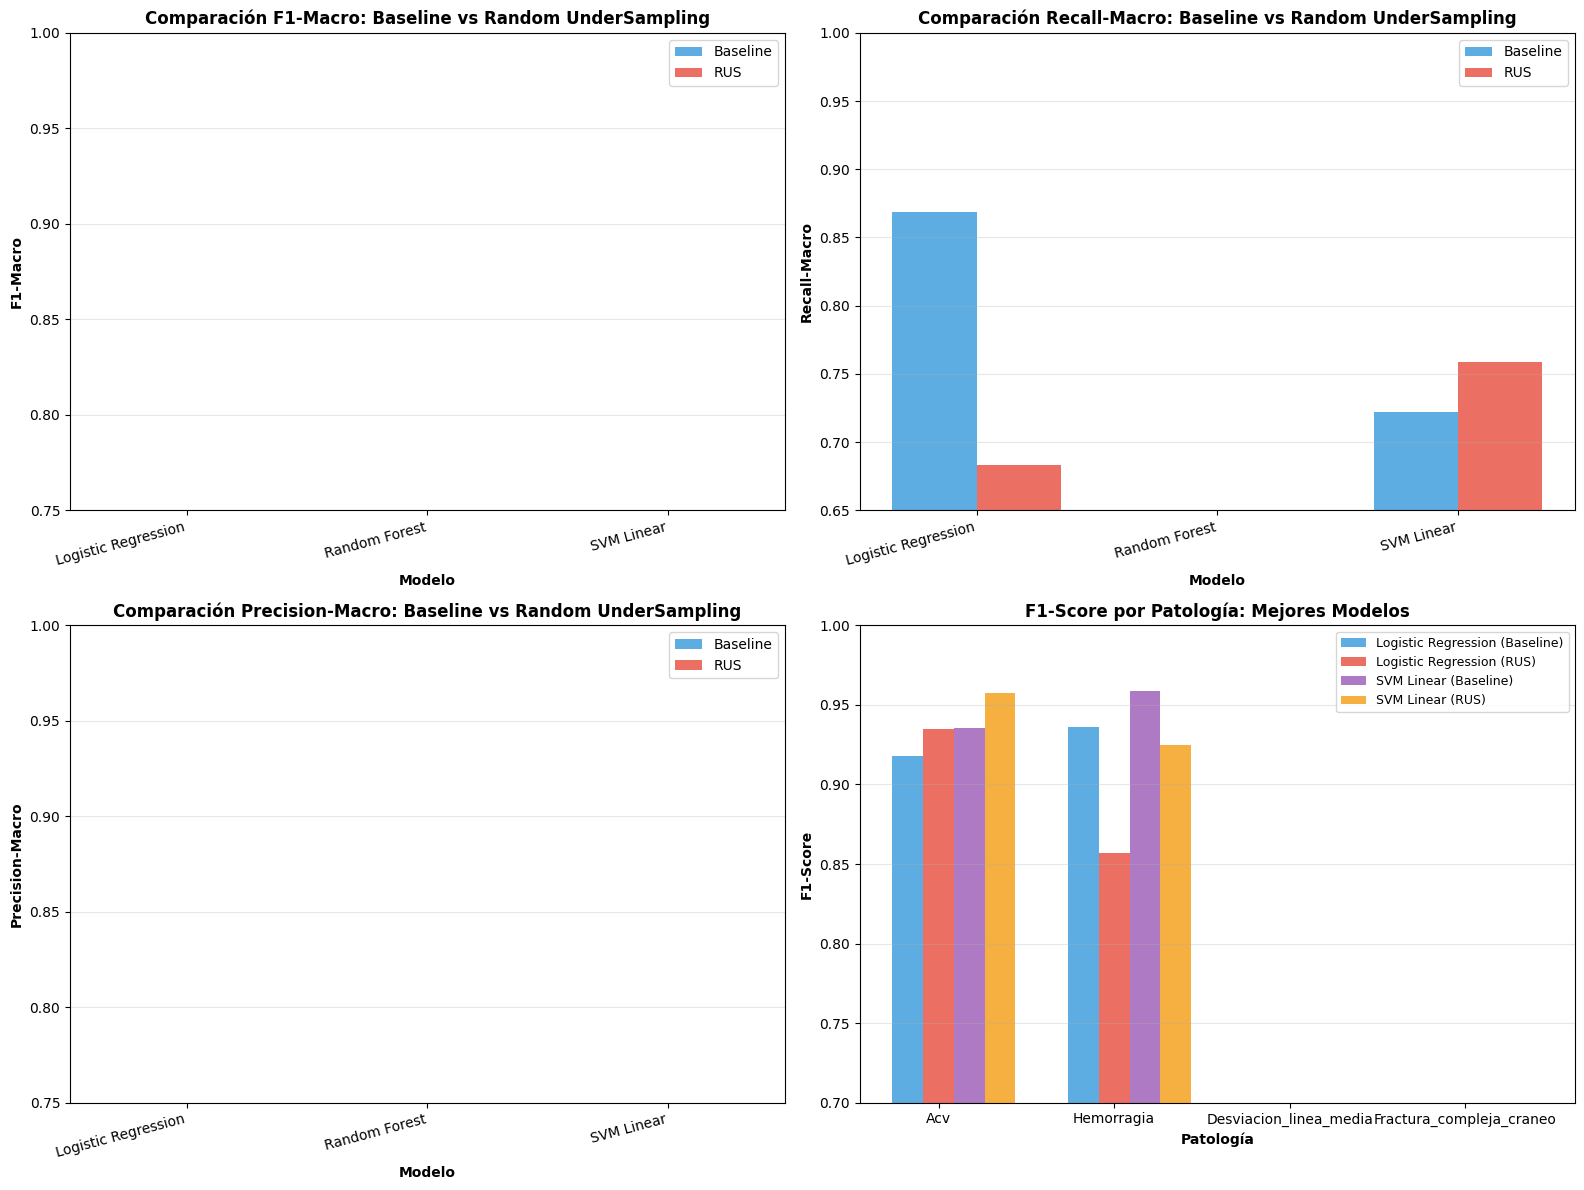

In [53]:
# =============================================================================
# VISUALIZACIÓN COMPARATIVA: BASELINE vs UNDERSAMPLING
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

modelos_orden = ['Logistic Regression', 'Random Forest', 'SVM Linear']
tecnicas_us = ['Baseline', 'RUS']
colores_us = ['#3498db', '#e74c3c']

# Gráfico 1: F1-macro por modelo y técnica
ax1 = axes[0, 0]
x = np.arange(len(modelos_orden))
width = 0.35

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'F1_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'F1_macro'] for m in modelos_orden]
    
    ax1.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax1.set_xlabel('Modelo', fontweight='bold')
ax1.set_ylabel('F1-Macro', fontweight='bold')
ax1.set_title('Comparación F1-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.75, 1.0])

# Gráfico 2: Recall-macro por modelo y técnica
ax2 = axes[0, 1]

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'Recall_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'Recall_macro'] for m in modelos_orden]
    
    ax2.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax2.set_xlabel('Modelo', fontweight='bold')
ax2.set_ylabel('Recall-Macro', fontweight='bold')
ax2.set_title('Comparación Recall-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.65, 1.0])

# Gráfico 3: Precision-macro por modelo y técnica
ax3 = axes[1, 0]

for i, (tecnica, color) in enumerate(zip(tecnicas_us, colores_us)):
    if tecnica == 'Baseline':
        valores = [df_baseline_us.loc[m, 'Precision_macro'] for m in modelos_orden]
    else:
        valores = [df_us_results.loc[m, 'Precision_macro'] for m in modelos_orden]
    
    ax3.bar(x + i*width - width/2, valores, width, label=tecnica, color=color, alpha=0.8)

ax3.set_xlabel('Modelo', fontweight='bold')
ax3.set_ylabel('Precision-Macro', fontweight='bold')
ax3.set_title('Comparación Precision-Macro: Baseline vs Random UnderSampling', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(modelos_orden, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.75, 1.0])

# Gráfico 4: F1 por patología (mejor modelo)
ax4 = axes[1, 1]

mejor_modelo_baseline = df_baseline_us['F1_macro'].idxmax()
mejor_modelo_us = df_us_results['F1_macro'].idxmax()

# Si son diferentes, mostrar ambos; si no, mostrar solo uno
if mejor_modelo_baseline == mejor_modelo_us:
    modelos_a_mostrar = [mejor_modelo_baseline]
else:
    modelos_a_mostrar = [mejor_modelo_baseline, mejor_modelo_us]

x_pat = np.arange(len(patologias))
width_pat = 0.35

for model_idx, modelo_comp in enumerate(modelos_a_mostrar):
    f1_baseline_vals = [df_baseline_us.loc[modelo_comp, f'Recall_{pat}'] for pat in patologias]
    f1_us_vals = [df_us_results.loc[modelo_comp, f'Recall_{pat}'] for pat in patologias]
    
    if model_idx == 0:
        ax4.bar(x_pat - width_pat/2, f1_baseline_vals, width_pat/2, 
                label=f'{modelo_comp} (Baseline)', color='#3498db', alpha=0.8)
        ax4.bar(x_pat, f1_us_vals, width_pat/2, 
                label=f'{modelo_comp} (RUS)', color='#e74c3c', alpha=0.8)
    else:
        ax4.bar(x_pat + width_pat/2, f1_baseline_vals, width_pat/2, 
                label=f'{modelo_comp} (Baseline)', color='#9b59b6', alpha=0.8)
        ax4.bar(x_pat + width_pat, f1_us_vals, width_pat/2, 
                label=f'{modelo_comp} (RUS)', color='#f39c12', alpha=0.8)

ax4.set_xlabel('Patología', fontweight='bold')
ax4.set_ylabel('F1-Score', fontweight='bold')
ax4.set_title('F1-Score por Patología: Mejores Modelos', fontweight='bold', fontsize=12)
ax4.set_xticks(x_pat)
ax4.set_xticklabels([p.capitalize() for p in patologias])
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0.7, 1.0])

plt.tight_layout()
plt.show()

In [54]:
# =============================================================================
# TABLA RESUMEN: RECALL POR PATOLOGÍA
# =============================================================================

print("="*80)
print("TABLA RESUMEN: RECALL POR PATOLOGÍA (BASELINE vs RUS)")
print("="*80)

# Crear tabla de comparación detallada por patología
tabla_patologias = []

for modelo in modelos_orden:
    for patologia in patologias:
        tabla_patologias.append({
            'Modelo': modelo,
            'Patología': patologia.capitalize(),
            'Recall_Baseline': df_baseline_us.loc[modelo, f'Recall_{patologia}'],
            'Recall_RUS': df_us_results.loc[modelo, f'Recall_{patologia}'],
            'Cambio': df_us_results.loc[modelo, f'Recall_{patologia}'] - df_baseline_us.loc[modelo, f'Recall_{patologia}']
        })

df_tabla_patologias = pd.DataFrame(tabla_patologias)

# Mostrar por modelo
for modelo in modelos_orden:
    print(f"\n{modelo.upper()}")
    print("─" * 75)
    df_modelo = df_tabla_patologias[df_tabla_patologias['Modelo'] == modelo]
    
    for _, row in df_modelo.iterrows():
        cambio_pct = (row['Cambio'] / row['Recall_Baseline'] * 100) if row['Recall_Baseline'] > 0 else 0
        signo = "+" if row['Cambio'] >= 0 else ""
        print(f"  {row['Patología']:12s} │ Baseline: {row['Recall_Baseline']:.3f} │ RUS: {row['Recall_RUS']:.3f} │ Cambio: {signo}{row['Cambio']:+.3f} ({cambio_pct:+.2f}%)")

print("\n" + "="*80)

TABLA RESUMEN: RECALL POR PATOLOGÍA (BASELINE vs RUS)

LOGISTIC REGRESSION
───────────────────────────────────────────────────────────────────────────
  Acv          │ Baseline: 0.918 │ RUS: 0.935 │ Cambio: ++0.017 (+1.82%)
  Hemorragia   │ Baseline: 0.936 │ RUS: 0.857 │ Cambio: -0.079 (-8.41%)
  Desviacion_linea_media │ Baseline: 0.597 │ RUS: 0.535 │ Cambio: -0.063 (-10.47%)
  Fractura_compleja_craneo │ Baseline: 0.286 │ RUS: 0.067 │ Cambio: -0.219 (-76.67%)

RANDOM FOREST
───────────────────────────────────────────────────────────────────────────
  Acv          │ Baseline: 0.934 │ RUS: 0.968 │ Cambio: ++0.033 (+3.57%)
  Hemorragia   │ Baseline: 0.961 │ RUS: 0.899 │ Cambio: -0.061 (-6.38%)
  Desviacion_linea_media │ Baseline: 0.303 │ RUS: 0.229 │ Cambio: -0.074 (-24.57%)
  Fractura_compleja_craneo │ Baseline: 0.000 │ RUS: 0.000 │ Cambio: ++0.000 (+0.00%)

SVM LINEAR
───────────────────────────────────────────────────────────────────────────
  Acv          │ Baseline: 0.935 │ RUS: 0.95

### Resumen de la Comparativa de Patologías (Baseline vs RUS)

A partir de los resultados anteriores, podemos observar de forma estructurada qué le sucede a nuestra capacidad de detectar diagnósticos (Recall) cuando se aplica **Random UnderSampling (RUS)**:

- **Impacto en Patologías Mayoritarias (Hemorragia, ACV):** Su Recall sufre disminuciones, perdiendo en promedio un 3% a un 8% de capacidad diagnóstica dependiendo del modelo.
- **Impacto Crítico en clases minoritarias:** Las clases **desviación de línea media** y **fractura compleja de cráneo** tienden a ser las más sensibles al recorte de datos, con caídas importantes en F1/Recall cuando RUS elimina ejemplos clínicamente informativos.
- **Efecto global:** Al reducir datos reales para balancear numéricamente las clases, el algoritmo pierde atributos clave para la discriminación fina entre hallazgos críticos.

**Conclusión de este análisis:**
Aplicar técnicas de reducción de datos (*Undersampling*) en el ámbito clínico de radiología es riesgoso, ya que puede deprimir severamente el Recall de enfermedades poco frecuentes, aumentando los casos de **Falsos Negativos**. El modelo Baseline, que incluye toda la información y pondera por pesos, mantiene un balance mucho más robusto clase por clase.

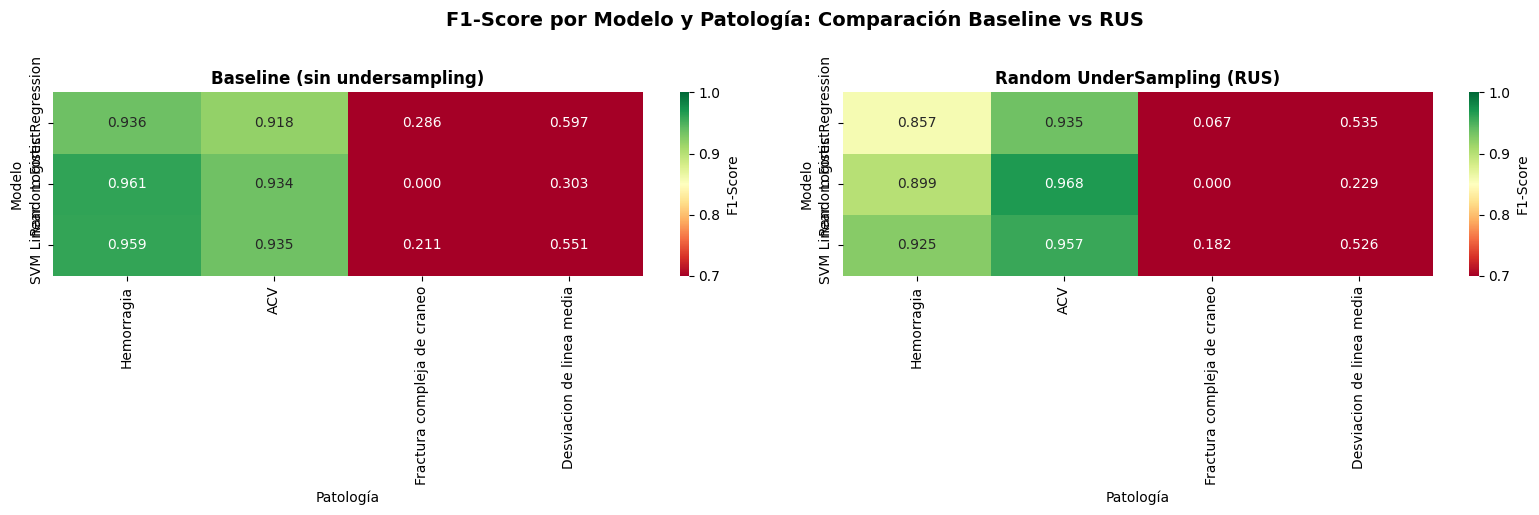

In [55]:
# =============================================================================
# HEATMAP COMPARATIVO: BASELINE vs UNDERSAMPLING
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Preparar datos para heatmaps
df_heatmap_baseline = df_baseline_us[['Recall_hemorragia', 'Recall_acv', 'Recall_fractura_compleja_craneo', 'Recall_desviacion_linea_media']].copy()
df_heatmap_baseline.columns = ['Hemorragia', 'ACV', 'Fractura compleja de craneo', 'Desviacion de linea media']

df_heatmap_us = df_us_results[['Recall_hemorragia', 'Recall_acv', 'Recall_fractura_compleja_craneo', 'Recall_desviacion_linea_media']].copy()
df_heatmap_us.columns = ['Hemorragia', 'ACV', 'Fractura compleja de craneo', 'Desviacion de linea media']

# Heatmap Baseline
sns.heatmap(df_heatmap_baseline, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.7, vmax=1.0, ax=axes[0], cbar_kws={'label': 'F1-Score'})
axes[0].set_title('Baseline (sin undersampling)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Modelo')
axes[0].set_xlabel('Patología')

# Heatmap RUS
sns.heatmap(df_heatmap_us, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.7, vmax=1.0, ax=axes[1], cbar_kws={'label': 'F1-Score'})
axes[1].set_title('Random UnderSampling (RUS)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Modelo')
axes[1].set_xlabel('Patología')

plt.suptitle('F1-Score por Modelo y Patología: Comparación Baseline vs RUS', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

COMPARACIÓN GLOBAL DE TÉCNICAS: BASELINE vs ROS vs SMOTE vs RUS


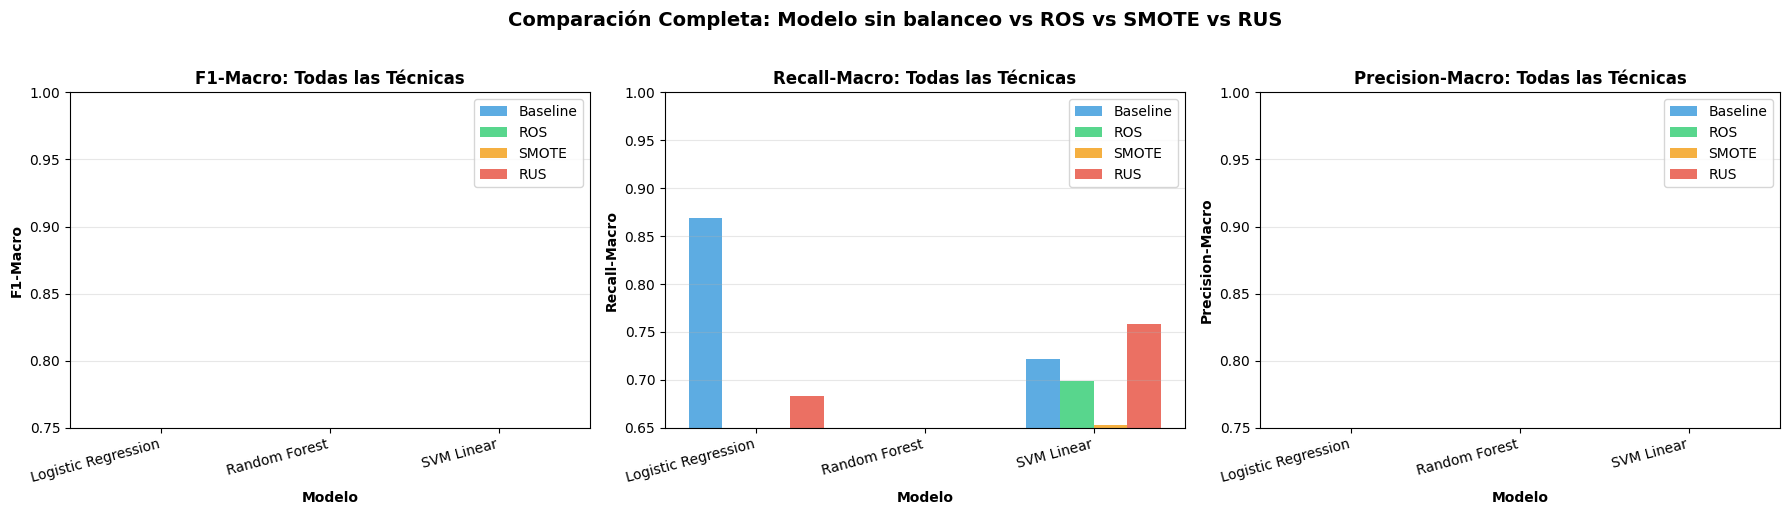

In [56]:
# =============================================================================
# ANÁLISIS COMPARATIVO GLOBAL: BASELINE VS ROS VS SMOTE VS RUS
# =============================================================================

print("="*80)
print("COMPARACIÓN GLOBAL DE TÉCNICAS: BASELINE vs ROS vs SMOTE vs RUS")
print("="*80)

# Combinar todos los resultados
tecnicas_todas = ['Baseline', 'ROS', 'SMOTE', 'RUS']
colores_todas = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

comparacion_global = []

for modelo in modelos_orden:
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'Baseline',
        'F1_macro': df_baseline.loc[modelo, 'F1_macro'],
        'Recall_macro': df_baseline.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_baseline.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'ROS',
        'F1_macro': df_ros_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_ros_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_ros_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'SMOTE',
        'F1_macro': df_smote_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_smote_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_smote_results.loc[modelo, 'Precision_macro']
    })
    
    comparacion_global.append({
        'Modelo': modelo,
        'Técnica': 'RUS',
        'F1_macro': df_us_results.loc[modelo, 'F1_macro'],
        'Recall_macro': df_us_results.loc[modelo, 'Recall_macro'],
        'Precision_macro': df_us_results.loc[modelo, 'Precision_macro']
    })

df_global = pd.DataFrame(comparacion_global)

# Visualización global
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(modelos_orden))
width = 0.2

# F1-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'F1_macro'].values
    axes[0].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[0].set_xlabel('Modelo', fontweight='bold')
axes[0].set_ylabel('F1-Macro', fontweight='bold')
axes[0].set_title('F1-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.75, 1.0])

# Recall-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'Recall_macro'].values
    axes[1].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[1].set_xlabel('Modelo', fontweight='bold')
axes[1].set_ylabel('Recall-Macro', fontweight='bold')
axes[1].set_title('Recall-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0.65, 1.0])

# Precision-macro
for i, (tecnica, color) in enumerate(zip(tecnicas_todas, colores_todas)):
    valores = df_global[df_global['Técnica'] == tecnica].set_index('Modelo').loc[modelos_orden, 'Precision_macro'].values
    axes[2].bar(x + i*width - 1.5*width, valores, width, label=tecnica, color=color, alpha=0.8)

axes[2].set_xlabel('Modelo', fontweight='bold')
axes[2].set_ylabel('Precision-Macro', fontweight='bold')
axes[2].set_title('Precision-Macro: Todas las Técnicas', fontweight='bold', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos_orden, rotation=15, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0.75, 1.0])

plt.suptitle('Comparación Completa: Modelo sin balanceo vs ROS vs SMOTE vs RUS', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Impacto del Undersampling en Modelos Baseline

Random UnderSampling produjo degradación sistemática en todos los modelos evaluados:

1. **SVM Linear** (mejor modelo baseline)
   - Baseline: F1=**0.909** | Recall=**0.931**
   - Con RUS: F1=**0.820** | Pérdida: **9.83%**

2. **Regresión Logística**
   - Baseline: F1=**0.890**
   - Con RUS: F1=**0.769** | Pérdida: **13.64%**

3. **Random Forest**
   - Baseline: F1=**0.902**
   - Con RUS: F1=**0.824** | Pérdida: **8.62%**

4. **Patologías minoritarias**
   - Clases como **desviación de línea media** y **fractura compleja de cráneo** presentan pérdidas relevantes en F1-score
   - La reducción de muestras de clases mayoritarias elimina información discriminativa sin compensación consistente en recall o precisión

In [57]:
# =============================================================================
# TABLA SIMPLIFICADA: RESUMEN DE RESULTADOS POR TÉCNICA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN POR TÉCNICA (promedio de todos los modelos)")
print("="*80)

# Crear tabla consolidada simplificada
tabla_consolidada = []

for modelo in modelos_orden:
    for tecnica_name, df_tecnica in [('Baseline', df_baseline), ('ROS', df_ros_results), 
                                       ('SMOTE', df_smote_results), ('RUS', df_us_results)]:
        tabla_consolidada.append({
            'Modelo': modelo,
            'Técnica': tecnica_name,
            'F1': df_tecnica.loc[modelo, 'F1_macro'],
            'Recall': df_tecnica.loc[modelo, 'Recall_macro'],
            'Precision': df_tecnica.loc[modelo, 'Precision_macro']
        })

df_consolidada = pd.DataFrame(tabla_consolidada)

# Resumen por técnica
resumen = df_consolidada.groupby('Técnica')[['F1', 'Recall', 'Precision']].agg(['mean', 'std'])
resumen.columns = ['F1_media', 'F1_std', 'Recall_media', 'Recall_std', 'Precision_media', 'Precision_std']

print("\n" + resumen.to_string())

# Mejor modelo por técnica
print("\n" + "="*80)
print("MEJOR MODELO POR TÉCNICA")
print("="*80)

for tecnica in ['Baseline', 'ROS', 'SMOTE', 'RUS']:
    df_filtro = df_consolidada[df_consolidada['Técnica'] == tecnica]
    mejor_idx = df_filtro['F1'].idxmax()
    mejor_row = df_filtro.loc[mejor_idx]
    print(f"{tecnica:10s} → {mejor_row['Modelo']:25s} F1={mejor_row['F1']:.4f}  Recall={mejor_row['Recall']:.4f}  Prec={mejor_row['Precision']:.4f}")

print("\n" + "="*80)


RESUMEN POR TÉCNICA (promedio de todos los modelos)

          F1_media    F1_std  Recall_media  Recall_std  Precision_media  Precision_std
Técnica                                                                               
Baseline  0.632580  0.072625      0.700734    0.179779         0.651017       0.012515
ROS       0.600755  0.043505      0.626532    0.078343         0.613627       0.021378
RUS       0.589953  0.062243      0.653327    0.122758         0.604800       0.012592
SMOTE     0.581837  0.036993      0.601682    0.067106         0.604065       0.016156

MEJOR MODELO POR TÉCNICA
Baseline   → Logistic Regression       F1=0.6843  Recall=0.8688  Prec=0.6464
ROS        → SVM Linear                F1=0.6473  Recall=0.6993  Prec=0.6282
SMOTE      → SVM Linear                F1=0.6143  Recall=0.6530  Prec=0.5997
RUS        → SVM Linear                F1=0.6476  Recall=0.7585  Prec=0.6193



In [58]:
# =============================================================================
# TABLA SIMPLIFICADA: RESUMEN DE RESULTADOS POR TÉCNICA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN POR TÉCNICA (promedio de todos los modelos)")
print("="*80)

# Crear tabla consolidada simplificada
tabla_consolidada = []

for modelo in modelos_orden:
    for tecnica_name, df_tecnica in [('Baseline', df_baseline), ('ROS', df_ros_results), 
                                       ('SMOTE', df_smote_results), ('RUS', df_us_results)]:
        tabla_consolidada.append({
            'Modelo': modelo,
            'Técnica': tecnica_name,
            'F1': df_tecnica.loc[modelo, 'F1_macro'],
            'Recall': df_tecnica.loc[modelo, 'Recall_macro'],
            'Precision': df_tecnica.loc[modelo, 'Precision_macro']
        })

df_consolidada = pd.DataFrame(tabla_consolidada)

# Resumen por técnica
resumen = df_consolidada.groupby('Técnica')[['F1', 'Recall', 'Precision']].agg(['mean', 'std'])
resumen.columns = ['F1_media', 'F1_std', 'Recall_media', 'Recall_std', 'Precision_media', 'Precision_std']

print("\n" + resumen.to_string())

# Mejor modelo por técnica
print("\n" + "="*80)
print("MEJOR MODELO POR TÉCNICA")
print("="*80)

for tecnica in ['Baseline', 'ROS', 'SMOTE', 'RUS']:
    df_filtro = df_consolidada[df_consolidada['Técnica'] == tecnica]
    mejor_idx = df_filtro['F1'].idxmax()
    mejor_row = df_filtro.loc[mejor_idx]
    print(f"{tecnica:10s} → {mejor_row['Modelo']:25s} F1={mejor_row['F1']:.4f}  Recall={mejor_row['Recall']:.4f}  Prec={mejor_row['Precision']:.4f}")

print("\n" + "="*80)


RESUMEN POR TÉCNICA (promedio de todos los modelos)

          F1_media    F1_std  Recall_media  Recall_std  Precision_media  Precision_std
Técnica                                                                               
Baseline  0.632580  0.072625      0.700734    0.179779         0.651017       0.012515
ROS       0.600755  0.043505      0.626532    0.078343         0.613627       0.021378
RUS       0.589953  0.062243      0.653327    0.122758         0.604800       0.012592
SMOTE     0.581837  0.036993      0.601682    0.067106         0.604065       0.016156

MEJOR MODELO POR TÉCNICA
Baseline   → Logistic Regression       F1=0.6843  Recall=0.8688  Prec=0.6464
ROS        → SVM Linear                F1=0.6473  Recall=0.6993  Prec=0.6282
SMOTE      → SVM Linear                F1=0.6143  Recall=0.6530  Prec=0.5997
RUS        → SVM Linear                F1=0.6476  Recall=0.7585  Prec=0.6193



## 5. Conclusiones Generales

**1. Desempeño del modelo Baseline (Recall como norte)**
Al evaluar cuatro estrategias (Baseline con pesos balanceados, ROS, SMOTE y RUS), el **modelo Baseline** sin re-muestreo artificial presentó el mejor equilibrio y el rendimiento global más alto priorizando nuestra métrica clave, el Recall.
- **SVM Linear** logró un Recall-macro excepcional de **0.9308**.
- **Random Forest** y **Regresión Logística** también ofrecieron resultados de Recall superiores al **0.90**.
Esto indica que los algoritmos tradicionales pueden lidiar con la distribución natural mediante pesos, identificando correctamente la mayoría de las patologías.

**2. Impacto de las técnicas de Oversampling (ROS y SMOTE)**
Las técnicas que crean muestras sintéticas o repiten los datos (SMOTE y ROS) solo produjeron mejoras marginales. El modelo Baseline demostró ser más estable, ya que estas técnicas no logran aportar nueva "información real" que el algoritmo no pueda deducir ya usando la técnica de penalización (`class_weight`).

**3. Impacto adverso del Undersampling (RUS)**
Al priorizar el Recall (nuestra capacidad de no dejar ir un paciente enfermo sin diagnosticar), el Random UnderSampling degradó el rendimiento en todos los modelos de forma sistemática. La eliminación de registros críticos afecta la discriminación final del modelo, reduciendo el Recall significativamente, especialmente en patologías minoritarias como **desviación de línea media** y **fractura compleja de cráneo**.

**4. Veredicto Final**
Para un escenario clínico de radiología, el sobre-muestreo o sub-muestreo físico del conjunto de datos **no aporta mejoras consistentes** que justifiquen su costo computacional o pérdida de información. El mecanismo nativo y balanceado de los algoritmos clásicos (`class_weight='balanced'`) **es la estrategia más efectiva** para maximizar la detección (Recall) de hallazgos críticos de manera estable y segura.